# Análise de Clustering de Clientes - Fase 5 (ML)

Este notebook visualiza e comenta os resultados do pipeline de Machine Learning que implementou clustering de clientes.

**Objetivo**: Segmentar clientes em grupos com base em:
- **Recência**: Dias desde último pagamento
- **Frequência**: Número de recebimentos/transações
- **Valor Monetário (RFM)**: Valor total recebido em BRL
- **Comportamento**: Taxa de pagamento em dia vs. atraso
- **Características**: Distribuição por categoria e país

## 1. Setup, Carregamento e Regra de Faixa de Valor

> Regra atual no treinamento: a coluna `faixa_valor_cliente` é criada por **tercis** do `valor_total_recebido_brl` (rank percentual).
- `medio_baixo_valor`: até 33.33%
- `alto_valor`: de 33.33% até 66.67%
- `muito_alto_valor`: acima de 66.67%

> Como os limites são calculados a cada execução, o notebook mostra os valores atualizados automaticamente quando os dados mudam.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

ml_path = Path("../data/ml")

cliente_clusterizado = pd.read_parquet(ml_path / "cliente_clusterizado.parquet")
model_comparison = pd.read_parquet(ml_path / "model_comparison.parquet")
features_cliente = pd.read_parquet(ml_path / "features_cliente.parquet")

print(f"Cliente Clusterizado: {cliente_clusterizado.shape}")
print(f"Model Comparison: {model_comparison.shape}")
print(f"Features Cliente: {features_cliente.shape}")

Cliente Clusterizado: (75, 13)
Model Comparison: (14, 10)
Features Cliente: (75, 29)


In [15]:
df_features = pd.read_parquet(ml_path / "features_cliente.parquet")
df_model_comparison = pd.read_parquet(ml_path / "model_comparison.parquet")
df_cliente_clusterizado = pd.read_parquet(ml_path / "cliente_clusterizado.parquet")

valor_col = df_features["valor_total_recebido_brl"].astype(float)
q33 = valor_col.quantile(1/3)
q66 = valor_col.quantile(2/3)

print("\nREGRAS DE CLASSIFICAÇÃO DE VALOR (dinâmicas por tercis)\n")
print(f"medio_baixo_valor: <= BRL {q33:,.2f}")
print(f"alto_valor: > BRL {q33:,.2f} e <= BRL {q66:,.2f}")
print(f"muito_alto_valor: > BRL {q66:,.2f}")

faixa_stats = (
    df_features.groupby("faixa_valor_cliente")["valor_total_recebido_brl"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_index()
    .round(2)
)

print("\nMÉDIAS E FAIXAS OBSERVADAS NO DATASET\n")
print(faixa_stats.to_string())

if "faixa_valor_cliente" in df_cliente_clusterizado.columns:
    print("\nDistribuição de faixa_valor_cliente na saída clusterizada:\n")
    print(df_cliente_clusterizado["faixa_valor_cliente"].value_counts().to_string())
else:
    print("\nAviso: coluna faixa_valor_cliente ainda não encontrada em cliente_clusterizado.")


REGRAS DE CLASSIFICAÇÃO DE VALOR (dinâmicas por tercis)

medio_baixo_valor: <= BRL 226,039,382.22
alto_valor: > BRL 226,039,382.22 e <= BRL 312,431,622.70
muito_alto_valor: > BRL 312,431,622.70

MÉDIAS E FAIXAS OBSERVADAS NO DATASET

                     count          mean        median           min           max
faixa_valor_cliente                                                               
alto_valor              25  2.788924e+08  2.919584e+08  2.268376e+08  3.124176e+08
medio_baixo_valor       25  1.154928e+08  1.102672e+08  7.140061e+07  2.244429e+08
muito_alto_valor        25  3.335748e+08  3.260065e+08  3.124597e+08  3.763911e+08

Distribuição de faixa_valor_cliente na saída clusterizada:

faixa_valor_cliente
medio_baixo_valor    25
muito_alto_valor     25
alto_valor           25


In [16]:
df_features.head()

,id_cliente,nome_cliente,pais_cliente,moeda_pais,data_cadastro_cliente,frequencia_recebimentos,valor_total_recebido_brl,valor_medio_recebido_brl,ultimo_pagamento,status_mais_comum,...,mix_cat_prestacao_de_servicos_nacionais,mix_cat_receita_de_assinaturas,mix_cat_receita_de_licenciamento_de_software,mix_cat_receita_financeira_sobre_aplicacoes,mix_cat_variacao_cambial_ativa,mix_cat_venda_de_produtos_exportacao,mix_cat_venda_de_produtos_nacionais,valor_total_recebido_brl_log1p,valor_medio_recebido_brl_log1p,faixa_valor_cliente
0,1,Ana Souza,BRASIL,BRL,2023-01-05,947,1.175323e+08,124110.151235,2025-12-31,Pago,...,0.085533,0.088701,0.116156,0.174234,0.093981,0.091869,0.117212,18.582224,11.728933,medio_baixo_valor
1,2,Carlos Mendes,PORTUGAL,EUR,2023-01-12,931,3.260065e+08,350168.126207,2025-12-31,Em aberto,...,0.087003,0.117078,0.107411,0.166488,0.092374,0.092374,0.078410,19.602428,12.766172,muito_alto_valor
2,3,Julien Martin,FRANCA,EUR,2023-01-18,945,3.178757e+08,336376.402948,2025-12-31,Em aberto,...,0.083598,0.102646,0.070899,0.171429,0.104762,0.091005,0.081481,19.577171,12.725989,muito_alto_valor
3,4,Michael Johnson,ESTADOS UNIDOS,USD,2023-01-25,904,2.856415e+08,315975.081170,2025-12-31,Em aberto,...,0.078540,0.089602,0.071903,0.195796,0.087389,0.095133,0.101770,19.470248,12.663422,alto_valor
4,5,Sophia Brown,CANADA,CAD,2023-02-02,949,2.396677e+08,252547.618349,2025-12-31,Atrasado,...,0.086407,0.089568,0.086407,0.189673,0.087460,0.108535,0.083246,19.294764,12.439359,alto_valor


In [17]:
df_model_comparison.head()

,model_name,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,rank_silhouette,rank_davies_bouldin,rank_calinski_harabasz,ranking_score
0,kmeans_k2,2,0.0,0.170401,1.927814,14.906468,1.0,2.0,1.0,0.250000
1,agglomerative_k2,2,0.0,0.154686,1.904616,13.109070,2.0,1.0,2.0,0.200000
2,agglomerative_k6,6,0.0,0.101509,2.040733,6.848960,5.0,4.0,10.0,0.052632
3,kmeans_k3,3,0.0,0.110129,2.506794,11.067447,3.0,13.0,3.0,0.052632
4,agglomerative_k5,5,0.0,0.099647,2.237653,7.600920,7.0,6.0,8.0,0.047619


In [18]:
df_cliente_clusterizado.head()

,id_cliente,nome_cliente,pais_cliente,moeda_pais,cluster,recencia_dias,frequencia_recebimentos,valor_total_recebido_brl,faixa_valor_cliente,taxa_pagamento_em_dia,taxa_pagamento_atrasado,perfil_cluster,modelo_vencedor
0,1,Ana Souza,BRASIL,BRL,0,0.0,947,1.175323e+08,medio_baixo_valor,0.843717,0.156283,recente|alta_frequencia|medio_baixo_valor|bom_...,kmeans_k2
1,2,Carlos Mendes,PORTUGAL,EUR,1,0.0,931,3.260065e+08,muito_alto_valor,0.852846,0.147154,recente|alta_frequencia|muito_alto_valor|bom_p...,kmeans_k2
2,3,Julien Martin,FRANCA,EUR,1,0.0,945,3.178757e+08,muito_alto_valor,0.847619,0.152381,recente|alta_frequencia|muito_alto_valor|bom_p...,kmeans_k2
3,4,Michael Johnson,ESTADOS UNIDOS,USD,1,0.0,904,2.856415e+08,alto_valor,0.860619,0.139381,recente|alta_frequencia|alto_valor|bom_pagador,kmeans_k2
4,5,Sophia Brown,CANADA,CAD,1,0.0,949,2.396677e+08,alto_valor,0.856691,0.143309,recente|alta_frequencia|alto_valor|bom_pagador,kmeans_k2


## 2. Análise do Modelo Vencedor

### 2.1 Qual modelo foi selecionado?

A seleção foi feita usando um **ranking composto** de 3 métricas de qualidade:
- **Silhueta** (0 a 1): Mede compacidade dos clusters (quanto maior, melhor)
- **Davies-Bouldin** (≥ 0): Razão média entre clusters (quanto menor, melhor)
- **Calinski-Harabasz** (≥ 0): Razão entre-clusters / intra-clusters (quanto maior, melhor)

O ranking usa a **média harmônica inversa** dos ranks para equilibrar as 3 métricas.

In [19]:
top_models = model_comparison.nlargest(5, 'ranking_score')[[
    'model_name', 'n_clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'ranking_score'
]].copy()

print("\nMELHORE MODELOS (por ranking_score)\n")
print(top_models.to_string(index=False))

best_model = model_comparison.iloc[0]
print(f"\n\nMODELO VENCEDOR: {best_model['model_name'].upper()}")
print(f"  • Clusters: {int(best_model['n_clusters'])}")
print(f"  • Silhueta: {best_model['silhouette']:.4f}")
print(f"  • Davies-Bouldin: {best_model['davies_bouldin']:.4f}")
print(f"  • Calinski-Harabasz: {best_model['calinski_harabasz']:.4f}")
print(f"  • Ranking Score: {best_model['ranking_score']:.6f}")


MELHORE MODELOS (por ranking_score)

      model_name  n_clusters  silhouette  davies_bouldin  calinski_harabasz  ranking_score
       kmeans_k2           2    0.170401        1.927814          14.906468       0.250000
agglomerative_k2           2    0.154686        1.904616          13.109070       0.200000
agglomerative_k6           6    0.101509        2.040733           6.848960       0.052632
       kmeans_k3           3    0.110129        2.506794          11.067447       0.052632
agglomerative_k5           5    0.099647        2.237653           7.600920       0.047619


MODELO VENCEDOR: KMEANS_K2
  • Clusters: 2
  • Silhueta: 0.1704
  • Davies-Bouldin: 1.9278
  • Calinski-Harabasz: 14.9065
  • Ranking Score: 0.250000


### 2.2 Comparativo: Modelos testados 

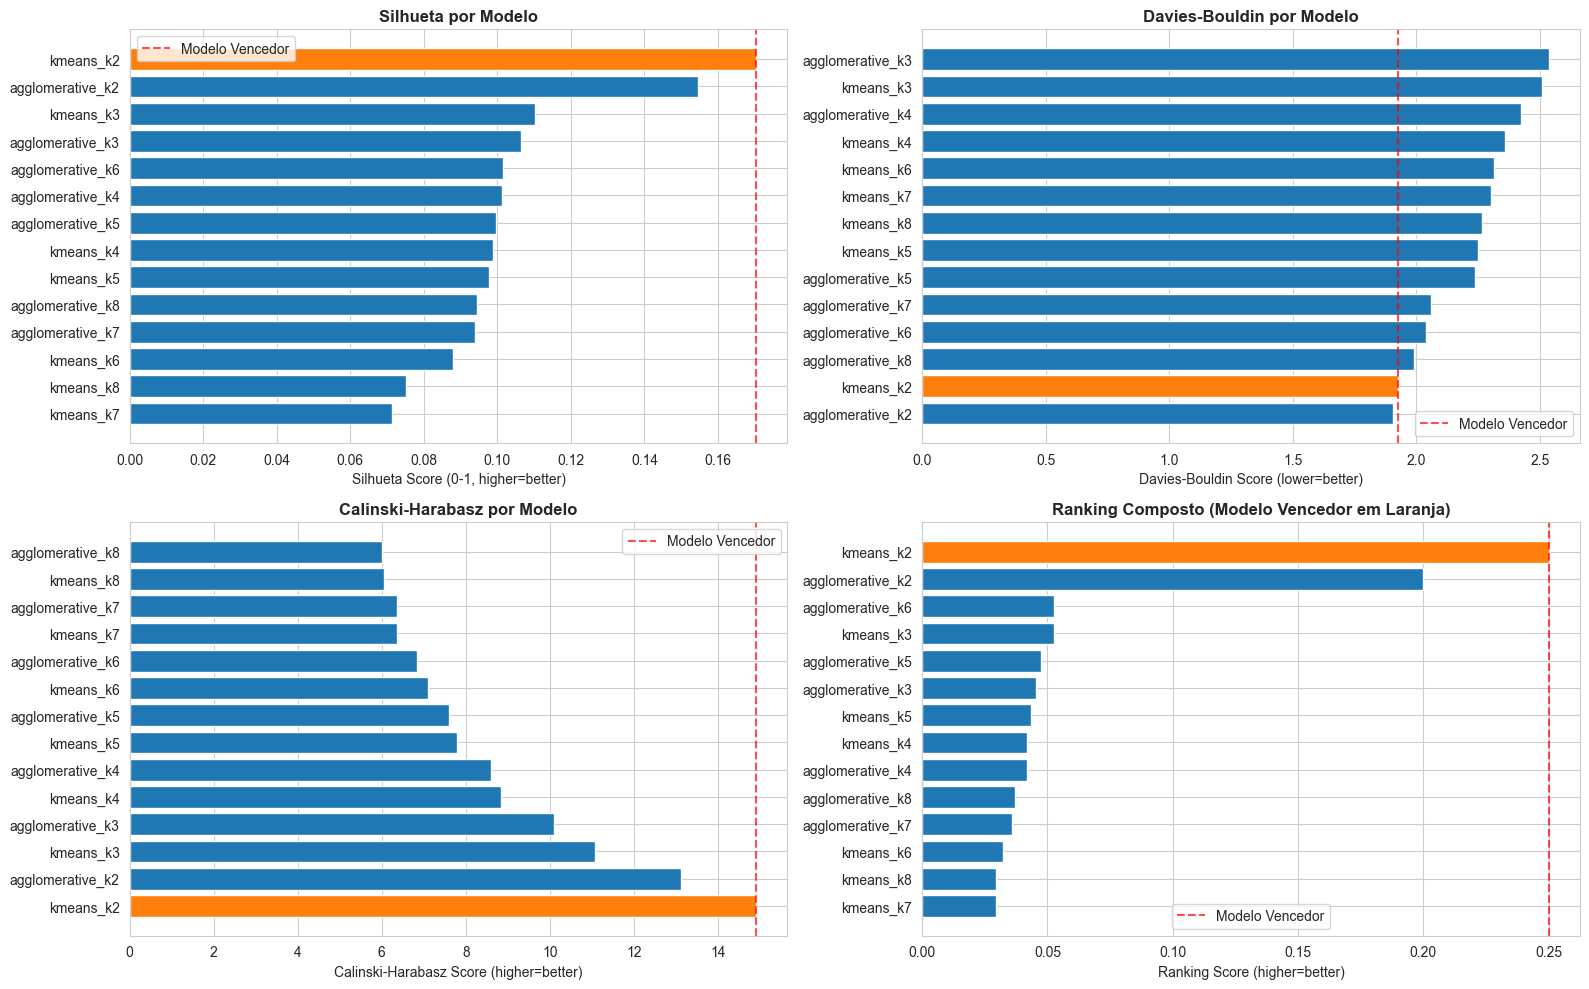

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Silhueta
ax = axes[0, 0]
model_comp_sorted = model_comparison.sort_values('silhouette', ascending=True)
colors = ['#ff7f0e' if x == best_model['model_name'] else '#1f77b4' for x in model_comp_sorted['model_name']]
ax.barh(model_comp_sorted['model_name'], model_comp_sorted['silhouette'], color=colors)
ax.set_xlabel('Silhueta Score (0-1, higher=better)')
ax.set_title('Silhueta por Modelo', fontweight='bold')
ax.axvline(best_model['silhouette'], color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Modelo Vencedor')
ax.legend()

# 2. Davies-Bouldin
ax = axes[0, 1]
model_comp_sorted = model_comparison.sort_values('davies_bouldin', ascending=True)
colors = ['#ff7f0e' if x == best_model['model_name'] else '#1f77b4' for x in model_comp_sorted['model_name']]
ax.barh(model_comp_sorted['model_name'], model_comp_sorted['davies_bouldin'], color=colors)
ax.set_xlabel('Davies-Bouldin Score (lower=better)')
ax.set_title('Davies-Bouldin por Modelo', fontweight='bold')
ax.axvline(best_model['davies_bouldin'], color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Modelo Vencedor')
ax.legend()

# 3. Calinski-Harabasz
ax = axes[1, 0]
model_comp_sorted = model_comparison.sort_values('calinski_harabasz', ascending=False)
colors = ['#ff7f0e' if x == best_model['model_name'] else '#1f77b4' for x in model_comp_sorted['model_name']]
ax.barh(model_comp_sorted['model_name'], model_comp_sorted['calinski_harabasz'], color=colors)
ax.set_xlabel('Calinski-Harabasz Score (higher=better)')
ax.set_title('Calinski-Harabasz por Modelo', fontweight='bold')
ax.axvline(best_model['calinski_harabasz'], color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Modelo Vencedor')
ax.legend()

# 4. Ranking Score
ax = axes[1, 1]
model_comp_sorted = model_comparison.sort_values('ranking_score', ascending=True)
colors = ['#ff7f0e' if x == best_model['model_name'] else '#1f77b4' for x in model_comp_sorted['model_name']]
ax.barh(model_comp_sorted['model_name'], model_comp_sorted['ranking_score'], color=colors)
ax.set_xlabel('Ranking Score (higher=better)')
ax.set_title('Ranking Composto (Modelo Vencedor em Laranja)', fontweight='bold')
ax.axvline(best_model['ranking_score'], color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Modelo Vencedor')
ax.legend()

plt.tight_layout()
plt.show()


## 3. Distribuição de Clusters


DISTRIBUIÇÃO DE CLIENTES POR CLUSTER

  Cluster 0:  21 clientes ( 28.0%)
  Cluster 1:  54 clientes ( 72.0%)


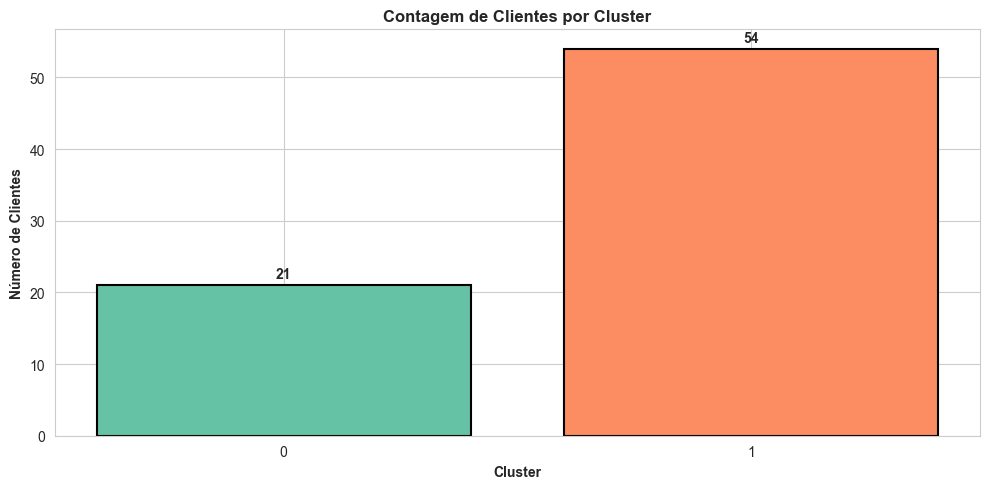

In [21]:
cluster_counts = cliente_clusterizado['cluster'].value_counts().sort_index()

print("\nDISTRIBUIÇÃO DE CLIENTES POR CLUSTER\n")
for cluster_id, count in cluster_counts.items():
    pct = 100 * count / len(cliente_clusterizado)
    print(f"  Cluster {cluster_id}: {count:3d} clientes ({pct:5.1f}%)")

# Visualizar distribuição (removido gráfico de pizza; exibir apenas barra)
fig, ax = plt.subplots(figsize=(10, 5))

colors_clusters = sns.color_palette('Set2', n_colors=len(cluster_counts))
ax.bar(cluster_counts.index, cluster_counts.values, color=colors_clusters, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Cluster', fontweight='bold')
ax.set_ylabel('Número de Clientes', fontweight='bold')
ax.set_title('Contagem de Clientes por Cluster', fontweight='bold', fontsize=12)
ax.set_xticks(cluster_counts.index)
for i, (cluster_id, count) in enumerate(zip(cluster_counts.index, cluster_counts.values)):
    ax.text(cluster_id, count + 1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Mapa de Usuários (K-Means)

> Clientes são projetados em 2D com PCA para mostrar a posição relativa dos clusters.

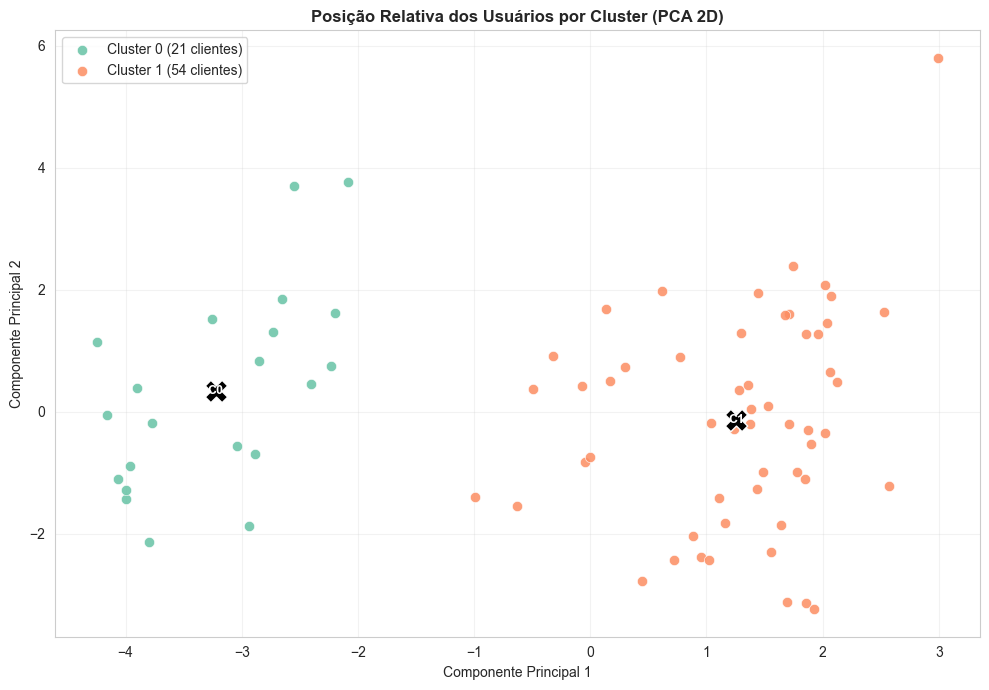

Variância explicada PCA: PC1=19.10% PC2=11.78%


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_base = (
    df_features.merge(
        cliente_clusterizado[["id_cliente", "cluster"]],
        on="id_cliente",
        how="inner",
    )
    .sort_values("id_cliente")
    .reset_index(drop=True)
)

feature_cols = [
    c for c in model_base.columns
    if c not in {"id_cliente", "nome_cliente", "data_cadastro_cliente", "cluster"}
]

x_raw = model_base[feature_cols].copy()
y = model_base["cluster"].astype(int).to_numpy()

numeric_cols = x_raw.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in x_raw.columns if c not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

x_processed = preprocessor.fit_transform(x_raw)
if hasattr(x_processed, "toarray"):
    x_processed = x_processed.toarray()

# Redução para 2D (visualização relativa)
pca = PCA(n_components=2, random_state=42)
x_2d = pca.fit_transform(x_processed)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set2", n_colors=len(np.unique(y)))

for i, cluster_id in enumerate(sorted(np.unique(y))):
    mask = y == cluster_id
    ax.scatter(
        x_2d[mask, 0],
        x_2d[mask, 1],
        s=55,
        alpha=0.85,
        color=palette[i],
        label=f"Cluster {cluster_id} ({mask.sum()} clientes)",
        edgecolors="white",
        linewidths=0.5,
    )

# Centróides aproximados no espaço 2D
for cluster_id in sorted(np.unique(y)):
    mask = y == cluster_id
    cx = x_2d[mask, 0].mean()
    cy = x_2d[mask, 1].mean()
    ax.scatter(cx, cy, s=260, marker="X", color="black", edgecolors="white", linewidths=1.0)
    ax.text(cx, cy, f"C{cluster_id}", color="white", ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_title("Posição Relativa dos Usuários por Cluster (PCA 2D)", fontweight="bold")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.legend(loc="best")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Variância explicada PCA:", f"PC1={pca.explained_variance_ratio_[0]:.2%}", f"PC2={pca.explained_variance_ratio_[1]:.2%}")

## 4. Visualização de Características por Cluster

C:\Users\darux\AppData\Local\Temp\ipykernel_22196\1500588928.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cliente_clusterizado, x='cluster', y=feature, ax=ax, palette='Set2')
C:\Users\darux\AppData\Local\Temp\ipykernel_22196\1500588928.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cliente_clusterizado, x='cluster', y=feature, ax=ax, palette='Set2')
C:\Users\darux\AppData\Local\Temp\ipykernel_22196\1500588928.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cliente_clusterizado, x='cluster', y=feature, ax=ax,

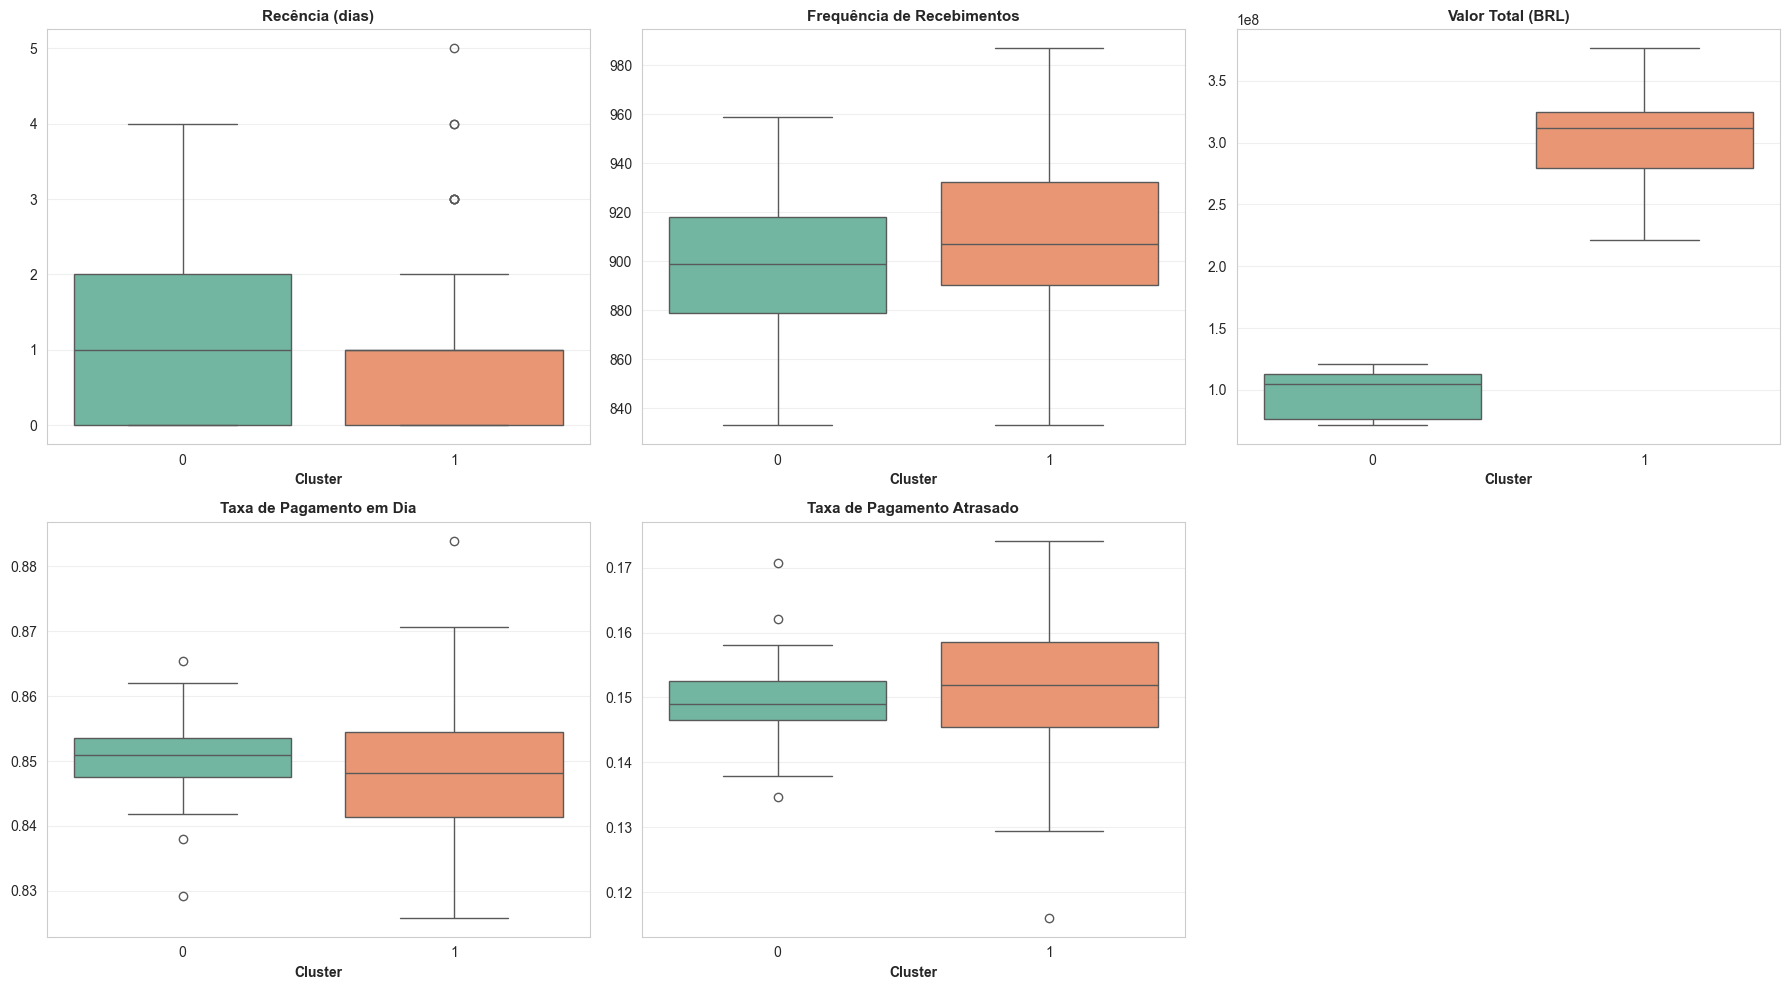

In [23]:
# Preparar dados para box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    ('recencia_dias', 'Recência (dias)', 0),
    ('frequencia_recebimentos', 'Frequência de Recebimentos', 1),
    ('valor_total_recebido_brl', 'Valor Total (BRL)', 2),
    ('taxa_pagamento_em_dia', 'Taxa de Pagamento em Dia', 3),
    ('taxa_pagamento_atrasado', 'Taxa de Pagamento Atrasado', 4),
]

for feature, title, idx in features_to_plot:
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    sns.boxplot(data=cliente_clusterizado, x='cluster', y=feature, ax=ax, palette='Set2')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Cluster', fontweight='bold')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.3)

# Remover subplot vazio
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## 5. Perfis Descritivos dos Clusters

In [24]:
print("\n PERFIS DE CLUSTER (Rótulos Automáticos)\n")

for cluster_id in sorted(cliente_clusterizado['cluster'].unique()):
    cluster_data = cliente_clusterizado[cliente_clusterizado['cluster'] == cluster_id]
    
    example_profile = cluster_data['perfil_cluster'].iloc[0]
    
    n_clientes = len(cluster_data)
    rec_media = cluster_data['recencia_dias'].mean()
    freq_media = cluster_data['frequencia_recebimentos'].mean()
    valor_media = cluster_data['valor_total_recebido_brl'].mean()
    taxa_pag = cluster_data['taxa_pagamento_em_dia'].mean() * 100
    
    print(f"   CLUSTER {cluster_id}")
    print(f"   Perfil: {example_profile}")
    print(f"   • Clientes: {n_clientes}")
    print(f"   • Recência média: {rec_media:.1f} dias")
    print(f"   • Frequência média: {freq_media:.1f} recebimentos")
    print(f"   • Valor total médio: BRL {valor_media:,.0f}")
    print(f"   • Taxa de pagamento em dia: {taxa_pag:.1f}%")

    if 'faixa_valor_cliente' in cluster_data.columns:
        faixa_dist = (cluster_data['faixa_valor_cliente'].value_counts(normalize=True) * 100).round(1)
        print("   • Mix faixa de valor (%):")
        for faixa, pct in faixa_dist.items():
            print(f"     - {faixa}: {pct:.1f}%")
    print()


 PERFIS DE CLUSTER (Rótulos Automáticos)

   CLUSTER 0
   Perfil: recente|alta_frequencia|medio_baixo_valor|bom_pagador
   • Clientes: 21
   • Recência média: 1.0 dias
   • Frequência média: 901.2 recebimentos
   • Valor total médio: BRL 95,170,209
   • Taxa de pagamento em dia: 85.0%
   • Mix faixa de valor (%):
     - medio_baixo_valor: 100.0%

   CLUSTER 1
   Perfil: recente|alta_frequencia|muito_alto_valor|bom_pagador
   • Clientes: 54
   • Recência média: 1.0 dias
   • Frequência média: 910.7 recebimentos
   • Valor total médio: BRL 300,007,899
   • Taxa de pagamento em dia: 84.9%
   • Mix faixa de valor (%):
     - muito_alto_valor: 46.3%
     - alto_valor: 46.3%
     - medio_baixo_valor: 7.4%



## 6. Dimensões Geográficas (País e Moeda)

In [25]:
print("\n DISTRIBUIÇÃO GEOGRÁFICA\n")

print("Países:")
print(cliente_clusterizado['pais_cliente'].value_counts())

print("\nMoedas:")
print(cliente_clusterizado['moeda_pais'].value_counts())

print("\n\nCruzamento: País x Cluster")
cross = pd.crosstab(cliente_clusterizado['pais_cliente'], cliente_clusterizado['cluster'], margins=True)
print(cross)


 DISTRIBUIÇÃO GEOGRÁFICA

Países:
pais_cliente
BRASIL            11
PORTUGAL          11
FRANCA            11
ESTADOS UNIDOS    11
CANADA            11
ARGENTINA         10
REINO UNIDO       10
Name: count, dtype: int64

Moedas:
moeda_pais
EUR    22
BRL    11
USD    11
CAD    11
ARS    10
GBP    10
Name: count, dtype: int64


Cruzamento: País x Cluster
cluster          0   1  All
pais_cliente               
ARGENTINA       10   0   10
BRASIL          11   0   11
CANADA           0  11   11
ESTADOS UNIDOS   0  11   11
FRANCA           0  11   11
PORTUGAL         0  11   11
REINO UNIDO      0  10   10
All             21  54   75


## 7. Conclusões e Insights Finais


1. **Modelo Selecionado**: O modelo **K-Means com k=2 clusters** foi escolhido usando um ranking composto de 3 métricas (Silhueta, Davies-Bouldin, Calinski-Harabasz).

2. **Qualidade**:
   - Silhueta, Davies-Bouldin e Calinski-Harabasz são exibidos na seção de comparação de modelos.
   - Como os dados evoluem a cada carga, os valores devem ser lidos da execução atual do notebook.

3. **Interpretabilidade**: Os clusters são rotulados com perfis descritivos baseados em:
   - **Recência**: Cliente recente (≤60 dias) vs. inativo (>60 dias)
   - **Frequência**: Alta frequência (≥20 transações) vs. baixa (<20)
   - **Valor**: `muito_alto_valor`, `alto_valor` e `medio_baixo_valor`
   - **Pagamento**: Bom pagador (≥70% em dia) vs. atrasa pagamento

4. **Regra de valor dinâmica no treino**:
   - A faixa de valor é calculada por tercis de `valor_total_recebido_brl` em cada execução.
   - Portanto, limites e médias por faixa podem mudar quando o dataset mudar.
   - A seção inicial do notebook mostra automaticamente os cortes e as médias atuais.

5. **Aplicabilidade**: Com 2 clusters, o modelo simplifica a segmentação para ações comerciais diretas:
   - Diferenciação por padrão de pagamento, frequência e faixa de valor.
   - Base para campanhas, política de crédito e acompanhamento da carteira.

In [26]:
print("\n AMOSTRA DA TABELA FINAL (10 clientes)\n")
display_cols = [
    'id_cliente', 'nome_cliente', 'pais_cliente', 'cluster',
    'recencia_dias', 'frequencia_recebimentos', 'valor_total_recebido_brl',
    'faixa_valor_cliente', 'taxa_pagamento_em_dia', 'perfil_cluster', 'modelo_vencedor'
]
print(cliente_clusterizado[display_cols].head(10).to_string(index=False))

print(f"\n\n Total de clientes analisados: {len(cliente_clusterizado)}")
print(f" Dataset pronto para BI/Power BI: data/ml/cliente_clusterizado.parquet")


 AMOSTRA DA TABELA FINAL (10 clientes)

 id_cliente    nome_cliente   pais_cliente  cluster  recencia_dias  frequencia_recebimentos  valor_total_recebido_brl faixa_valor_cliente  taxa_pagamento_em_dia                                        perfil_cluster modelo_vencedor
          1       Ana Souza         BRASIL        0            0.0                      947              1.175323e+08   medio_baixo_valor               0.843717 recente|alta_frequencia|medio_baixo_valor|bom_pagador       kmeans_k2
          2   Carlos Mendes       PORTUGAL        1            0.0                      931              3.260065e+08    muito_alto_valor               0.852846  recente|alta_frequencia|muito_alto_valor|bom_pagador       kmeans_k2
          3   Julien Martin         FRANCA        1            0.0                      945              3.178757e+08    muito_alto_valor               0.847619  recente|alta_frequencia|muito_alto_valor|bom_pagador       kmeans_k2
          4 Michael Johnson ESTADOS